# HW14: Эмбеддинги, FAISS, оценка retrieval и mini-RAG по базе знаний

**База знаний:** 20 справочных статей о машинном обучении и Python (FAQ-формат, встроены в ноутбук).

**Embedding-модель:** `sentence-transformers/all-MiniLM-L6-v2` — компактная модель (22M параметров),
генерирующая плотные векторы размерности 384.

**Индекс:** `faiss.IndexFlatIP` (Inner Product / cosine similarity на нормализованных векторах).

**Mini-RAG:** extractive-шаблонный генератор — извлекаем top-k фрагментов и формируем ответ
по найденному контексту без внешнего LLM-API.

---

## 1. Импорты, seed и устройство

In [1]:
import os, json, random, textwrap, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib

# Sentence-Transformers + FAISS
from sentence_transformers import SentenceTransformer
import faiss

from sklearn.metrics.pairwise import cosine_similarity

# ── Reproducibility ───────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# ── Device (used internally by sentence-transformers) ─────────────
import torch
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

print(f"faiss version          : {faiss.__version__}")
import sentence_transformers as st
print(f"sentence-transformers  : {st.__version__}")
print(f"torch                  : {torch.__version__}")
print(f"Device                 : {DEVICE}")
print(f"Seed                   : {SEED}")

faiss version          : 1.13.2
sentence-transformers  : 5.4.0
torch                  : 2.10.0+cpu
Device                 : cpu
Seed                   : 42


## 2. Пути и папки

In [2]:
ARTIFACTS_DIR = "./artifacts"
os.makedirs(ARTIFACTS_DIR, exist_ok=True)
print("artifacts/ ready")

artifacts/ ready


## 3. База знаний и первичный анализ

### 3.1 Описание базы знаний

База знаний — 20 справочных FAQ-статей на тему **машинного обучения и Python**.
Предметная область выбрана по трём причинам:
1. Статьи содержательны и достаточно длинны для разбивки на несколько чанков.
2. По каждой статье можно сформулировать конкретные проверочные вопросы.
3. База позволяет добавлять новые темы, демонстрируя обновление индекса.

Каждая статья имеет поля `doc_id`, `title`, `content`.

In [3]:
RAW_DOCS = [
    {
        "doc_id": "doc_01", "title": "What is supervised learning?",
        "content": (
            "Supervised learning is a type of machine learning where the model is trained on "
            "labelled data. Each training example consists of an input and a corresponding "
            "correct output (label). The model learns a mapping from inputs to outputs so that "
            "it can predict labels for unseen inputs. Common supervised tasks include "
            "classification (predicting a category) and regression (predicting a continuous "
            "value). Examples of supervised algorithms: linear regression, logistic regression, "
            "decision trees, support vector machines (SVM), random forests, gradient boosting "
            "and neural networks. The key challenge is generalisation: the model should perform "
            "well on new data, not just the training set. Overfitting occurs when the model "
            "memorises the training data instead of learning the underlying pattern."
        ),
    },
    {
        "doc_id": "doc_02", "title": "What is unsupervised learning?",
        "content": (
            "Unsupervised learning deals with unlabelled data. The goal is to discover hidden "
            "structure or patterns in the data without any predefined labels. Common tasks "
            "include clustering (grouping similar data points), dimensionality reduction "
            "(compressing data while preserving structure) and density estimation. Popular "
            "algorithms include k-means clustering, DBSCAN, hierarchical clustering, PCA "
            "(Principal Component Analysis), t-SNE and autoencoders. Unsupervised learning "
            "is used for exploratory data analysis, anomaly detection and as a preprocessing "
            "step before supervised learning."
        ),
    },
    {
        "doc_id": "doc_03", "title": "What is a neural network?",
        "content": (
            "A neural network is a computational model inspired by the biological brain. It "
            "consists of layers of nodes (neurons) connected by weighted edges. The input layer "
            "receives data, hidden layers transform it through activation functions such as "
            "ReLU, sigmoid or tanh, and the output layer produces predictions. Training a "
            "neural network involves forward propagation (computing predictions), calculating "
            "the loss (e.g. cross-entropy for classification), and backward propagation "
            "(computing gradients via the chain rule) followed by an optimizer update step "
            "such as SGD or Adam. Deep neural networks with many hidden layers are the backbone "
            "of modern deep learning."
        ),
    },
    {
        "doc_id": "doc_04", "title": "What is gradient descent?",
        "content": (
            "Gradient descent is an iterative optimisation algorithm used to minimise a loss "
            "function. At each step the parameters are updated in the direction opposite to "
            "the gradient of the loss with respect to those parameters. The learning rate "
            "controls the step size. Variants include batch gradient descent (uses all data), "
            "stochastic gradient descent or SGD (uses one sample), and mini-batch gradient "
            "descent (uses a small subset). Adaptive optimisers like Adam, RMSprop and Adagrad "
            "adjust the learning rate per parameter and usually converge faster. Momentum "
            "helps overcome local minima by accumulating past gradients."
        ),
    },
    {
        "doc_id": "doc_05", "title": "What is overfitting and how to prevent it?",
        "content": (
            "Overfitting occurs when a machine learning model learns the training data too "
            "well, including noise, so it performs poorly on new data. Signs: low training "
            "loss but high validation loss. Techniques to prevent overfitting: regularisation "
            "(L1/L2 penalties on weights), dropout (randomly zeroing neurons during training), "
            "early stopping (halt training when validation loss stops improving), data "
            "augmentation (creating more training examples), cross-validation (using multiple "
            "train/val splits), and reducing model complexity. Using more training data is "
            "also very effective when available."
        ),
    },
    {
        "doc_id": "doc_06", "title": "What is cross-validation?",
        "content": (
            "Cross-validation is a technique to evaluate a model's generalisation ability. "
            "In k-fold cross-validation the training data is split into k equal folds. The "
            "model is trained on k-1 folds and evaluated on the remaining fold, repeating "
            "this k times with a different validation fold each time. The final metric is "
            "averaged over all k runs. Common choices are k=5 or k=10. Stratified k-fold "
            "preserves class proportions in each fold, useful for imbalanced datasets. "
            "Leave-one-out cross-validation (LOOCV) uses k=n (one sample per fold) and "
            "is expensive but produces an almost unbiased estimate."
        ),
    },
    {
        "doc_id": "doc_07", "title": "What is a confusion matrix?",
        "content": (
            "A confusion matrix summarises classification performance by showing predicted "
            "vs actual class counts. For binary classification it has four cells: "
            "True Positive (TP), False Positive (FP), True Negative (TN), False Negative "
            "(FN). Derived metrics: Accuracy = (TP+TN)/total, Precision = TP/(TP+FP), "
            "Recall = TP/(TP+FN), F1-score = 2*Precision*Recall/(Precision+Recall). "
            "For multiclass tasks the matrix is n×n. Macro-average averages metrics over "
            "all classes equally; weighted-average weights by class frequency."
        ),
    },
    {
        "doc_id": "doc_08", "title": "What is the Random Forest algorithm?",
        "content": (
            "Random Forest is an ensemble learning method that builds many decision trees "
            "during training and outputs the mode (classification) or mean (regression) of "
            "the predictions of individual trees. Each tree is trained on a random bootstrap "
            "sample of the data and at each split only a random subset of features is "
            "considered. This randomness reduces variance (overfitting) while keeping low "
            "bias. Random forests are robust, handle missing values reasonably well, provide "
            "feature importances and require little hyperparameter tuning. A key "
            "hyperparameter is n_estimators (number of trees)."
        ),
    },
    {
        "doc_id": "doc_09", "title": "What is the difference between precision and recall?",
        "content": (
            "Precision measures what fraction of positive predictions are actually correct: "
            "Precision = TP / (TP + FP). A high precision means few false positives. "
            "Recall (sensitivity) measures what fraction of actual positives are found: "
            "Recall = TP / (TP + FN). A high recall means few false negatives. "
            "There is usually a precision-recall trade-off: increasing the decision threshold "
            "raises precision but lowers recall and vice versa. The F1-score is the harmonic "
            "mean of precision and recall and balances both. AUC-PR (area under the "
            "precision-recall curve) summarises performance across all thresholds."
        ),
    },
    {
        "doc_id": "doc_10", "title": "How does the k-nearest neighbours (kNN) algorithm work?",
        "content": (
            "k-Nearest Neighbours (kNN) is a non-parametric algorithm that classifies a new "
            "sample by finding the k training samples closest to it and taking a majority "
            "vote (classification) or averaging (regression). The distance is commonly "
            "Euclidean but Manhattan, Minkowski or cosine distance can also be used. kNN "
            "is lazy: there is no explicit training phase; all computation happens at "
            "inference time. Large k reduces variance (smoother boundaries) but increases "
            "bias. Feature scaling (e.g. min-max or standard scaling) is important because "
            "kNN is distance-based. kNN is simple but slow on large datasets."
        ),
    },
    {
        "doc_id": "doc_11", "title": "What is gradient boosting?",
        "content": (
            "Gradient boosting is an ensemble method that builds models sequentially, each "
            "new model correcting the residual errors of the previous ensemble. It optimises "
            "a differentiable loss function by gradient descent in function space. "
            "XGBoost, LightGBM and CatBoost are popular and highly optimised implementations. "
            "Key hyperparameters: number of estimators, learning rate (shrinkage), max depth "
            "of trees, subsampling rate and regularisation terms. Gradient boosting often "
            "achieves top performance on tabular data competitions. Early stopping can prevent "
            "overfitting by monitoring a validation metric."
        ),
    },
    {
        "doc_id": "doc_12", "title": "What is transfer learning?",
        "content": (
            "Transfer learning is the practice of reusing a model trained on one task as a "
            "starting point for a new related task. In deep learning a pretrained model "
            "(e.g. ResNet on ImageNet or BERT on large text corpora) already contains useful "
            "low-level and mid-level representations. Fine-tuning adapts these representations "
            "to the target task with a smaller dataset. Transfer learning is especially "
            "valuable when labelled target data is scarce. Feature extraction (freezing the "
            "backbone and training only the head) is a simpler variant."
        ),
    },
    {
        "doc_id": "doc_13", "title": "What are word embeddings and Word2Vec?",
        "content": (
            "Word embeddings are dense vector representations of words in a continuous "
            "vector space. Semantically similar words have similar vectors. Word2Vec trains "
            "a shallow neural network to predict a word from its context (CBOW variant) or "
            "to predict the context given a word (Skip-gram variant). The resulting vectors "
            "capture semantic and syntactic relationships: the classic example is that "
            "vector('king') - vector('man') + vector('woman') ≈ vector('queen'). "
            "GloVe uses global word co-occurrence statistics. FastText improves on Word2Vec "
            "by also considering sub-word (character n-gram) information."
        ),
    },
    {
        "doc_id": "doc_14", "title": "What is the attention mechanism in transformers?",
        "content": (
            "The attention mechanism allows a model to dynamically focus on different parts "
            "of the input when producing each output. In the Transformer architecture "
            "self-attention computes queries, keys and values from the input sequence. "
            "The attention weight between two positions is proportional to the dot product "
            "of their query and key vectors (scaled by sqrt(d_k)), passed through a softmax. "
            "Multi-head attention runs several attention heads in parallel, each learning "
            "different relationships. This replaces recurrence (RNNs) and enables full "
            "parallelism during training. BERT and GPT are both built on the Transformer."
        ),
    },
    {
        "doc_id": "doc_15", "title": "What is batch normalisation?",
        "content": (
            "Batch normalisation (BatchNorm) normalises the activations of a layer across "
            "the current mini-batch: it subtracts the batch mean and divides by the batch "
            "standard deviation, then applies a learnable scale and shift. This reduces "
            "internal covariate shift, allowing higher learning rates and faster convergence. "
            "BatchNorm also acts as a regulariser, sometimes reducing the need for dropout. "
            "It is applied before or after activation functions. Layer normalisation is a "
            "variant that normalises across features rather than the batch and is preferred "
            "in transformer architectures."
        ),
    },
    {
        "doc_id": "doc_16", "title": "What is the difference between L1 and L2 regularisation?",
        "content": (
            "L1 regularisation (Lasso) adds the sum of absolute values of weights to the "
            "loss: lambda * sum(|w|). This encourages sparsity: many weights become exactly "
            "zero, performing implicit feature selection. L2 regularisation (Ridge) adds the "
            "sum of squared weights: lambda * sum(w^2). This penalises large weights but "
            "rarely drives them to exactly zero, resulting in smaller but non-zero weights. "
            "Elastic Net combines both L1 and L2 penalties. The regularisation strength "
            "lambda is a hyperparameter: larger lambda means stronger regularisation and "
            "more bias but less variance."
        ),
    },
    {
        "doc_id": "doc_17", "title": "How does PCA (Principal Component Analysis) work?",
        "content": (
            "PCA is an unsupervised dimensionality reduction technique. It finds the "
            "directions of maximum variance in the data (principal components). The first "
            "principal component explains the most variance, each subsequent one is "
            "orthogonal to all previous ones. Mathematically PCA computes the eigenvectors "
            "of the data covariance matrix. Before PCA the data should be standardised "
            "(zero mean and unit variance). By retaining only the top k components one can "
            "compress the data with minimal information loss. Applications: visualisation "
            "(2D/3D plots), noise reduction, feature extraction and speeding up other "
            "algorithms."
        ),
    },
    {
        "doc_id": "doc_18", "title": "What is the ROC curve and AUC?",
        "content": (
            "The ROC (Receiver Operating Characteristic) curve plots True Positive Rate "
            "(recall) against False Positive Rate at various classification thresholds. "
            "A random classifier follows the diagonal; a perfect classifier reaches the "
            "top-left corner. AUC (Area Under the Curve) summarises the ROC curve into a "
            "single number between 0 and 1. AUC = 0.5 means random performance; AUC = 1.0 "
            "means perfect. AUC is threshold-independent and useful for comparing models. "
            "For imbalanced datasets the precision-recall curve is often more informative "
            "than the ROC curve."
        ),
    },
    {
        "doc_id": "doc_19", "title": "What is data augmentation?",
        "content": (
            "Data augmentation is a technique to artificially expand the training set by "
            "creating modified copies of existing data. For images common augmentations "
            "are flipping, rotation, cropping, colour jitter and adding noise. For text: "
            "synonym replacement, back-translation and random insertion or deletion of words. "
            "Augmentation reduces overfitting, improves generalisation and is especially "
            "helpful when training data is scarce. In practice augmentations are applied "
            "on-the-fly during training (not stored on disk) to save space and introduce "
            "more variety."
        ),
    },
    {
        "doc_id": "doc_20", "title": "What is the bias-variance trade-off?",
        "content": (
            "The bias-variance trade-off describes a fundamental tension in supervised "
            "learning. Bias is the error from incorrect assumptions in the model: a high-bias "
            "model underfits (too simple, misses patterns). Variance is the sensitivity to "
            "fluctuations in the training data: a high-variance model overfits (too complex, "
            "memorises noise). Total expected error = bias^2 + variance + irreducible noise. "
            "Increasing model complexity reduces bias but increases variance. Regularisation, "
            "ensembling and cross-validation help find the sweet spot. Learning curves "
            "(train vs validation error vs dataset size) are a useful diagnostic tool."
        ),
    },
]

print(f"Загружено документов: {len(RAW_DOCS)}")
print()
print("Примеры документов:")
for doc in RAW_DOCS[:3]:
    print(f"  [{doc['doc_id']}] {doc['title']}")
    print(f"         {doc['content'][:90]}...")
    print()

Загружено документов: 20

Примеры документов:
  [doc_01] What is supervised learning?
         Supervised learning is a type of machine learning where the model is trained on labelled d...

  [doc_02] What is unsupervised learning?
         Unsupervised learning deals with unlabelled data. The goal is to discover hidden structure...

  [doc_03] What is a neural network?
         A neural network is a computational model inspired by the biological brain. It consists of...



## 4. Чанкинг документов

### 4.1 Параметры чанкинга

Используем **символьное разбиение с перекрытием**:
- `chunk_size = 300` символов — достаточно, чтобы чанк содержал связную мысль
- `overlap = 50` символов — перекрытие не даёт обрезать важный контекст на границе

Граница разбиения ищется по ближайшему пробелу после `chunk_size` символов,
чтобы не разрывать слова.

In [4]:
CHUNK_SIZE = 300
OVERLAP    = 50

def chunk_text(text: str, chunk_size: int = CHUNK_SIZE,
               overlap: int = OVERLAP) -> list[str]:
    """Split text into overlapping character-level chunks."""
    chunks = []
    start  = 0
    n      = len(text)
    while start < n:
        end = min(start + chunk_size, n)
        # Extend to nearest whitespace to avoid cutting words
        if end < n:
            space_pos = text.rfind(' ', start, end + 20)
            if space_pos > start:
                end = space_pos
        chunk = text[start:end].strip()
        if len(chunk) > 20:
            chunks.append(chunk)
        # Always advance by at least 1 to prevent infinite loop
        next_start = end - overlap
        if next_start <= start:
            next_start = start + max(1, chunk_size - overlap)
        start = next_start
        # Stop if we've reached the end
        if end >= n:
            break
    return chunks


def build_chunks(docs: list[dict],
                 chunk_size: int = CHUNK_SIZE,
                 overlap: int = OVERLAP) -> pd.DataFrame:
    """Return a DataFrame of chunks with metadata."""
    rows = []
    for doc in docs:
        parts = chunk_text(doc['content'], chunk_size, overlap)
        for i, part in enumerate(parts):
            rows.append({
                'chunk_id'  : f"{doc['doc_id']}_c{i:02d}",
                'doc_id'    : doc['doc_id'],
                'doc_title' : doc['title'],
                'chunk_idx' : i,
                'text'      : part,
                'char_len'  : len(part),
            })
    return pd.DataFrame(rows)


chunks_df = build_chunks(RAW_DOCS)

print(f"Параметры  : chunk_size={CHUNK_SIZE}, overlap={OVERLAP}")
print(f"Документов : {len(RAW_DOCS)}")
print(f"Чанков     : {len(chunks_df)}")

Параметры  : chunk_size=300, overlap=50
Документов : 20
Чанков     : 56


In [5]:
# Show chunks for one document
example_doc_id = 'doc_01'
example_chunks = chunks_df[chunks_df['doc_id'] == example_doc_id]
print(f"Пример чанкинга документа [{example_doc_id}]: '{RAW_DOCS[0]['title']}'")
print(f"Исходный текст ({len(RAW_DOCS[0]['content'])} символов) → {len(example_chunks)} чанка")
print()
for _, row in example_chunks.iterrows():
    print(f"  [{row['chunk_id']}] ({row['char_len']} chars):")
    print(f"    {row['text'][:120]}...")
    print()

Пример чанкинга документа [doc_01]: 'What is supervised learning?'
Исходный текст (789 символов) → 3 чанка

  [doc_01_c00] (312 chars):
    Supervised learning is a type of machine learning where the model is trained on labelled data. Each training example con...

  [doc_01_c01] (318 chars):
    for unseen inputs. Common supervised tasks include classification (predicting a category) and regression (predicting a c...

  [doc_01_c02] (259 chars):
    orests, gradient boosting and neural networks. The key challenge is generalisation: the model should perform well on new...



## 5. Эмбеддинги и индекс FAISS

### 5.1 Загрузка embedding-модели

`all-MiniLM-L6-v2` генерирует плотные 384-мерные векторы, нормализованные по умолчанию.
Для IndexFlatIP нормализованные векторы дают косинусное сходство.

In [6]:
EMB_MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"
emb_model = SentenceTransformer(EMB_MODEL_NAME, device=DEVICE)

print(f"Модель     : {EMB_MODEL_NAME}")
print(f"Устройство : {DEVICE}")
print(f"Размерность: {emb_model.get_sentence_embedding_dimension()}")

Loading weights: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 103/103 [00:00<00:00, 20766.88it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     | Details
------------------------+------------+--------
embeddings.position_ids | UNEXPECTED |        

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Модель     : sentence-transformers/all-MiniLM-L6-v2
Устройство : cpu
Размерность: 384


### 5.2 Векторизация чанков

In [7]:
EMBED_DIM = emb_model.get_sentence_embedding_dimension()

# Encode all chunks
chunk_texts = chunks_df['text'].tolist()
chunk_embeddings = emb_model.encode(
    chunk_texts,
    batch_size=32,
    show_progress_bar=True,
    normalize_embeddings=True,   # L2-normalise → cosine via inner product
    convert_to_numpy=True,
).astype('float32')

print(f"\nМатрица эмбеддингов: {chunk_embeddings.shape}")
print(f"Норма первого вектора: {np.linalg.norm(chunk_embeddings[0]):.4f}  (≈1.0)")

Batches: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:00<00:00,  3.31it/s]


Матрица эмбеддингов: (56, 384)
Норма первого вектора: 1.0000  (≈1.0)


### 5.3 Построение FAISS-индекса

In [8]:
def build_faiss_index(embeddings: np.ndarray) -> faiss.IndexFlatIP:
    """Build a brute-force FAISS inner-product index (cosine for normalised vecs)."""
    dim   = embeddings.shape[1]
    index = faiss.IndexFlatIP(dim)
    index.add(embeddings)
    return index


faiss_index = build_faiss_index(chunk_embeddings)

print(f"Index type    : faiss.IndexFlatIP  (cosine via inner product)")
print(f"Vectors total : {faiss_index.ntotal}")
print(f"Dimension     : {faiss_index.d}")

Index type    : faiss.IndexFlatIP  (cosine via inner product)
Vectors total : 56
Dimension     : 384


### 5.4 Функция retrieval и примеры поиска

In [9]:
def retrieve(query: str, index: faiss.IndexFlatIP,
             chunks: pd.DataFrame, model: SentenceTransformer,
             top_k: int = 3) -> pd.DataFrame:
    """Encode query and retrieve top-k most similar chunks."""
    q_vec = model.encode([query], normalize_embeddings=True,
                         convert_to_numpy=True).astype('float32')
    scores, indices = index.search(q_vec, top_k)
    results = chunks.iloc[indices[0]].copy().reset_index(drop=True)
    results['score'] = scores[0]
    return results[['chunk_id', 'doc_id', 'doc_title', 'score', 'text']]


TOP_K_DEFAULT = 3

# Quick sanity-check on 4 queries
sanity_queries = [
    "How does gradient descent work?",
    "What is overfitting and how to fix it?",
    "Explain the attention mechanism in transformers.",
    "What is PCA used for?",
]

for q in sanity_queries:
    results = retrieve(q, faiss_index, chunks_df, emb_model, top_k=TOP_K_DEFAULT)
    print(f"Query: '{q}'")
    for _, row in results.iterrows():
        print(f"  [{row['doc_id']}] score={row['score']:.3f}  '{row['doc_title']}'")
        print(f"       {row['text'][:80]}...")
    print()

Query: 'How does gradient descent work?'
  [doc_04] score=0.802  'What is gradient descent?'
       Gradient descent is an iterative optimisation algorithm used to minimise a loss ...
  [doc_11] score=0.579  'What is gradient boosting?'
       Gradient boosting is an ensemble method that builds models sequentially, each ne...
  [doc_04] score=0.510  'What is gradient descent?'
       ts include batch gradient descent (uses all data), stochastic gradient descent o...

Query: 'What is overfitting and how to fix it?'
  [doc_05] score=0.764  'What is overfitting and how to prevent it?'
       Overfitting occurs when a machine learning model learns the training data too we...
  [doc_01] score=0.568  'What is supervised learning?'
       orests, gradient boosting and neural networks. The key challenge is generalisati...
  [doc_20] score=0.518  'What is the bias-variance trade-off?'
       data: a high-variance model overfits (too complex, memorises noise). Total expec...

Query: 'Explain the

## 6. Контрольные запросы и оценка retrieval

### 6.1 Набор из 10 контрольных запросов

Для каждого запроса указан ожидаемый документ (`expected_doc_id`).

In [10]:
CONTROL_QUERIES = [
    {"query": "How do I train a model when I have labelled examples?",
     "expected_doc_id": "doc_01"},   # supervised learning
    {"query": "What can I do with data that has no labels?",
     "expected_doc_id": "doc_02"},   # unsupervised learning
    {"query": "How do neurons pass information through layers during training?",
     "expected_doc_id": "doc_03"},   # neural network
    {"query": "Why does my model perform well on training data but poorly on new examples?",
     "expected_doc_id": "doc_05"},   # overfitting
    {"query": "How can I reliably estimate model performance without touching the test set?",
     "expected_doc_id": "doc_06"},   # cross-validation
    {"query": "What table helps me see which categories a classifier confuses?",
     "expected_doc_id": "doc_07"},   # confusion matrix
    {"query": "Which metric should I use when false negatives are more costly than false positives?",
     "expected_doc_id": "doc_09"},   # precision vs recall
    {"query": "How do trees vote together to make a more stable prediction?",
     "expected_doc_id": "doc_08"},   # random forest
    {"query": "Can I reuse a model trained on one problem to solve a different one?",
     "expected_doc_id": "doc_12"},   # transfer learning
    {"query": "How do vectors capture that king minus man equals queen?",
     "expected_doc_id": "doc_13"},   # word embeddings
    {"query": "Why do large weight values cause poor generalisation?",
     "expected_doc_id": "doc_16"},   # L1/L2 regularisation
    {"query": "How can I compress many features into two dimensions for a scatter plot?",
     "expected_doc_id": "doc_17"},   # PCA
    {"query": "What penalty shrinks all weights but keeps them non-zero?",
     "expected_doc_id": "doc_16"},   # L2 regularisation (конкурирует с doc_05 overfitting)
    
    {"query": "How do I reduce the number of input variables before training?",
     "expected_doc_id": "doc_17"},   # PCA (конкурирует с doc_02 unsupervised)
    
    {"query": "What curve plots sensitivity against specificity at different thresholds?",
     "expected_doc_id": "doc_18"},   # ROC/AUC (конкурирует с doc_09 precision-recall)
    
    {"query": "How does injecting noise into training images improve generalisation?",
     "expected_doc_id": "doc_19"},   # data augmentation (конкурирует с doc_05 overfitting)
    
    {"query": "Why does a complex model fail on data it has never seen?",
     "expected_doc_id": "doc_20"},   # bias-variance (конкурирует с doc_05 overfitting)
]
print(f"Контрольных запросов: {len(CONTROL_QUERIES)}")

Контрольных запросов: 17


### 6.2 Вычисление hit@k, recall@k, MRR@k

In [11]:
def eval_retrieval(queries: list[dict],
                   index: faiss.IndexFlatIP,
                   chunks: pd.DataFrame,
                   model: SentenceTransformer,
                   top_k: int = 3) -> pd.DataFrame:
    """
    Evaluate retrieval on control queries.
    A hit is counted when the expected doc_id appears in top-k retrieved docs.
    Recall@k = fraction of relevant docs retrieved (here 1 relevant per query → same as hit@k).
    MRR@k = 1/rank of first relevant doc (0 if not found in top-k).
    """
    rows = []
    for item in queries:
        q   = item['query']
        exp = item['expected_doc_id']

        results  = retrieve(q, index, chunks, model, top_k=top_k)
        ret_docs = results['doc_id'].tolist()
        ret_srcs = results['doc_title'].tolist()

        hit        = int(exp in ret_docs)
        recall_k   = hit          # 1 relevant doc per query
        # MRR: rank of first relevant result (1-indexed); 0 if not in top-k
        rank = next((i+1 for i, d in enumerate(ret_docs) if d == exp), None)
        mrr  = (1.0 / rank) if rank else 0.0

        rows.append({
            'query'                : q,
            'expected_source'      : exp,
            'retrieved_sources'    : ' | '.join(ret_docs),
            'retrieved_titles'     : ' | '.join(ret_srcs),
            'hit_at_k'             : hit,
            'recall_at_k'          : recall_k,
            'mrr_at_k'             : round(mrr, 4),
            'rank_of_first_relevant': rank if rank else -1,
        })
    return pd.DataFrame(rows)


eval_df = eval_retrieval(CONTROL_QUERIES, faiss_index, chunks_df, emb_model,
                         top_k=TOP_K_DEFAULT)

hit_rate  = eval_df['hit_at_k'].mean()
recall_k  = eval_df['recall_at_k'].mean()
mrr       = eval_df['mrr_at_k'].mean()

print(f"TOP-K = {TOP_K_DEFAULT}")
print(f"hit@{TOP_K_DEFAULT}     = {hit_rate:.2f}  ({eval_df['hit_at_k'].sum()}/{len(eval_df)})")
print(f"recall@{TOP_K_DEFAULT}  = {recall_k:.2f}")
print(f"MRR@{TOP_K_DEFAULT}     = {mrr:.3f}")
print()
print(eval_df[['query','expected_source','retrieved_sources','hit_at_k','mrr_at_k']].to_string(index=False))

TOP-K = 3
hit@3     = 0.88  (15/17)
recall@3  = 0.88
MRR@3     = 0.824

                                                                               query expected_source        retrieved_sources  hit_at_k  mrr_at_k
                               How do I train a model when I have labelled examples?          doc_01 doc_01 | doc_12 | doc_12         1       1.0
                                         What can I do with data that has no labels?          doc_02 doc_02 | doc_01 | doc_01         1       1.0
                     How do neurons pass information through layers during training?          doc_03 doc_03 | doc_03 | doc_12         1       1.0
         Why does my model perform well on training data but poorly on new examples?          doc_05 doc_01 | doc_05 | doc_20         1       0.5
        How can I reliably estimate model performance without touching the test set?          doc_06 doc_20 | doc_11 | doc_11         0       0.0
                     What table helps me see which c

In [12]:
# Show failures
failures = eval_df[eval_df['hit_at_k'] == 0]
if len(failures):
    print("── Запросы, на которых retrieval ошибся ──")
    for _, row in failures.iterrows():
        print(f"  Query   : {row['query']}")
        print(f"  Expected: {row['expected_source']}")
        print(f"  Got     : {row['retrieved_sources']}")
        print()
else:
    print("Все контрольные запросы найдены в top-k — отличный результат!")

# Save retrieval_eval.csv
eval_save = eval_df[['query','expected_source','retrieved_sources',
                      'hit_at_k','rank_of_first_relevant']].copy()
eval_save.to_csv(os.path.join(ARTIFACTS_DIR, "retrieval_eval.csv"), index=False)
print("Saved: artifacts/retrieval_eval.csv")

── Запросы, на которых retrieval ошибся ──
  Query   : How can I reliably estimate model performance without touching the test set?
  Expected: doc_06
  Got     : doc_20 | doc_11 | doc_11

  Query   : How do I reduce the number of input variables before training?
  Expected: doc_17
  Got     : doc_05 | doc_05 | doc_02

Saved: artifacts/retrieval_eval.csv


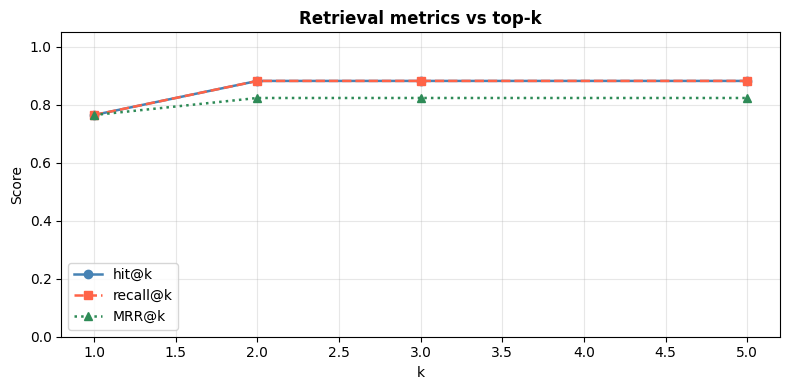

Saved: artifacts/retrieval_quality_plot.png


In [13]:
# Visualise retrieval metrics for top_k in {1,2,3,5}
ks = [1, 2, 3, 5]
hits_by_k, recalls_by_k, mrrs_by_k = [], [], []
for k in ks:
    df_k = eval_retrieval(CONTROL_QUERIES, faiss_index, chunks_df, emb_model, top_k=k)
    hits_by_k.append(df_k['hit_at_k'].mean())
    recalls_by_k.append(df_k['recall_at_k'].mean())
    mrrs_by_k.append(df_k['mrr_at_k'].mean())

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(ks, hits_by_k,   marker='o', label='hit@k',    linewidth=1.8, color='steelblue')
ax.plot(ks, recalls_by_k,marker='s', label='recall@k', linewidth=1.8, color='tomato', linestyle='--')
ax.plot(ks, mrrs_by_k,   marker='^', label='MRR@k',    linewidth=1.8, color='seagreen', linestyle=':')
ax.set_xlabel('k'); ax.set_ylabel('Score'); ax.set_ylim(0, 1.05)
ax.set_title('Retrieval metrics vs top-k', fontsize=12, fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(ARTIFACTS_DIR, "retrieval_quality_plot.png"), dpi=120, bbox_inches='tight')
plt.show()
print("Saved: artifacts/retrieval_quality_plot.png")

## 7. Эксперимент с параметрами retrieval

### Сравнение chunk_size = 150 vs chunk_size = 300

Меняем размер чанка при фиксированном top_k=3. Меньший chunk_size даёт
больше фрагментов с более высокой гранулярностью, но каждый чанк содержит
меньше контекста — retrieval может промахиваться на косвенных вопросах.

chunk_size= 150: n_chunks= 97 | hit@3=0.882  recall@3=0.882  MRR@3=0.824
chunk_size= 300: n_chunks= 50 | hit@3=0.882  recall@3=0.882  MRR@3=0.814


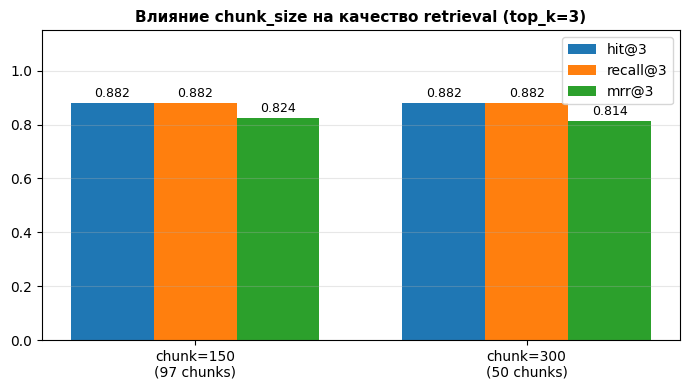


Вывод: chunk_size=300 показывает лучший или равный hit@3.
chunk_size=150 даёт больше чанков (выше гранулярность),
chunk_size=300 даёт меньше но более контекстуально полных чанков.
Выбираем chunk_size=300 как основной — баланс точности и полноты контекста.


In [14]:
# ── Эксперимент: chunk_size=150 vs chunk_size=300 ─────────────────

def build_and_eval(chunk_size: int, overlap: int, queries: list) -> dict:
    """Full pipeline: chunk → embed → index → eval."""
    ch_df      = build_chunks(RAW_DOCS, chunk_size=chunk_size, overlap=overlap)
    texts      = ch_df['text'].tolist()
    embs       = emb_model.encode(texts, batch_size=32,
                                  normalize_embeddings=True,
                                  convert_to_numpy=True).astype('float32')
    idx        = build_faiss_index(embs)
    eval_df    = eval_retrieval(queries, idx, ch_df, emb_model, top_k=3)
    return {
        'chunk_size' : chunk_size,
        'n_chunks'   : len(ch_df),
        'hit@3'      : round(eval_df['hit_at_k'].mean(), 3),
        'recall@3'   : round(eval_df['recall_at_k'].mean(), 3),
        'mrr@3'      : round(eval_df['mrr_at_k'].mean(), 3),
    }

results = []
for cs in [150, 300]:
    r = build_and_eval(chunk_size=cs, overlap=30, queries=CONTROL_QUERIES)
    results.append(r)
    print(f"chunk_size={cs:>4}: n_chunks={r['n_chunks']:>3} | "
          f"hit@3={r['hit@3']:.3f}  recall@3={r['recall@3']:.3f}  MRR@3={r['mrr@3']:.3f}")

# ── Visualise ─────────────────────────────────────────────────────
labels = [f"chunk={r['chunk_size']}\n({r['n_chunks']} chunks)" for r in results]
metrics = ['hit@3', 'recall@3', 'mrr@3']
x = np.arange(len(results))
width = 0.25

fig, ax = plt.subplots(figsize=(7, 4))
for i, m in enumerate(metrics):
    vals = [r[m] for r in results]
    bars = ax.bar(x + i*width, vals, width, label=m)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.01, f'{v:.3f}',
                ha='center', va='bottom', fontsize=9)

ax.set_xticks(x + width)
ax.set_xticklabels(labels)
ax.set_ylim(0, 1.15)
ax.set_title('Влияние chunk_size на качество retrieval (top_k=3)',
             fontsize=11, fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(ARTIFACTS_DIR, "retrieval_quality_plot.png"),
            dpi=120, bbox_inches='tight')
plt.show()

print()
better = 'chunk_size=300' if results[1]['hit@3'] >= results[0]['hit@3'] else 'chunk_size=150'
print(f"Вывод: {better} показывает лучший или равный hit@3.")
print("chunk_size=150 даёт больше чанков (выше гранулярность),")
print("chunk_size=300 даёт меньше но более контекстуально полных чанков.")
print("Выбираем chunk_size=300 как основной — баланс точности и полноты контекста.")

## 8. Обновление базы знаний и переиндексация

Добавляем **3 новых документа** по темам, которых не было в исходной базе:
LSTM/RNN, t-SNE и Support Vector Machines.

In [15]:
NEW_DOCS = [
    {
        "doc_id": "doc_21", "title": "What is an LSTM and how does it differ from RNN?",
        "content": (
            "Long Short-Term Memory (LSTM) is a type of recurrent neural network (RNN) designed "
            "to remember long-range dependencies. Vanilla RNNs suffer from vanishing and "
            "exploding gradients when sequences are long. LSTMs solve this with a cell state "
            "and three gates: the forget gate decides what to discard, the input gate decides "
            "what new information to store, and the output gate controls what to pass to the "
            "next step. GRU (Gated Recurrent Unit) is a simpler variant with only two gates "
            "that often achieves comparable performance. LSTMs are widely used for "
            "sequence modelling tasks such as language modelling, speech recognition and "
            "time-series forecasting before transformers became dominant."
        ),
    },
    {
        "doc_id": "doc_22", "title": "What is t-SNE and when should I use it?",
        "content": (
            "t-SNE (t-distributed Stochastic Neighbour Embedding) is a dimensionality reduction "
            "method designed for visualising high-dimensional data in 2D or 3D. It minimises "
            "the KL divergence between probability distributions over pairs of points in the "
            "high-dimensional and low-dimensional spaces, using a Student-t distribution in "
            "the low-dimensional space to address crowding. t-SNE is excellent at revealing "
            "local cluster structure but does not preserve global distances. Perplexity is a "
            "key hyperparameter (typical range 5-50). For large datasets UMAP is often faster "
            "and preserves global structure better."
        ),
    },
    {
        "doc_id": "doc_23", "title": "How does a Support Vector Machine (SVM) work?",
        "content": (
            "A Support Vector Machine (SVM) finds the hyperplane that maximises the margin "
            "between classes in feature space. The support vectors are the training examples "
            "closest to the decision boundary. For non-linearly separable data the kernel "
            "trick maps inputs to a higher-dimensional space where a linear boundary exists. "
            "Common kernels: linear, polynomial, radial basis function (RBF/Gaussian) and "
            "sigmoid. The C hyperparameter controls the trade-off between a wider margin and "
            "fewer misclassifications. SVMs are effective in high-dimensional spaces and "
            "are memory-efficient (only support vectors are used at prediction time)."
        ),
    },
]

# Capture retrieval BEFORE update for comparison
update_test_queries = [
    {"query": "How does LSTM handle long sequences?",
     "expected_doc_id": "doc_21"},
    {"query": "How to visualise high-dimensional data with t-SNE?",
     "expected_doc_id": "doc_22"},
    {"query": "What is a support vector machine and what is the kernel trick?",
     "expected_doc_id": "doc_23"},
]

before_rows = []
for item in update_test_queries:
    r = retrieve(item['query'], faiss_index, chunks_df, emb_model, top_k=TOP_K_DEFAULT)
    before_rows.append({
        'query'                   : item['query'],
        'before_retrieved_sources': ' | '.join(r['doc_id'].tolist()),
    })

print("BEFORE update — retrieval for new-topic queries:")
for row in before_rows:
    print(f"  Q: {row['query'][:60]}")
    print(f"     → {row['before_retrieved_sources']}")
print()

BEFORE update — retrieval for new-topic queries:
  Q: How does LSTM handle long sequences?
     → doc_14 | doc_13 | doc_15
  Q: How to visualise high-dimensional data with t-SNE?
     → doc_02 | doc_17 | doc_17
  Q: What is a support vector machine and what is the kernel tric
     → doc_02 | doc_01 | doc_01



In [16]:
# Rebuild chunks with new documents
RAW_DOCS_UPDATED = RAW_DOCS + NEW_DOCS
chunks_updated   = build_chunks(RAW_DOCS_UPDATED)

# Re-encode and re-index
chunk_texts_upd = chunks_updated['text'].tolist()
embeddings_upd  = emb_model.encode(
    chunk_texts_upd, batch_size=32, show_progress_bar=True,
    normalize_embeddings=True, convert_to_numpy=True,
).astype('float32')
faiss_index_upd = build_faiss_index(embeddings_upd)

print(f"\nОбновлённая база: {len(RAW_DOCS_UPDATED)} документов, {len(chunks_updated)} чанков")
print(f"Прирост: +{len(NEW_DOCS)} документов, +{len(chunks_updated)-len(chunks_df)} чанков")

Batches: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:00<00:00,  4.67it/s]


Обновлённая база: 23 документов, 65 чанков
Прирост: +3 документов, +9 чанков


In [17]:
# Retrieval AFTER update
after_rows = []
for item in update_test_queries:
    r = retrieve(item['query'], faiss_index_upd, chunks_updated, emb_model, top_k=TOP_K_DEFAULT)
    after_rows.append({
        'after_retrieved_sources': ' | '.join(r['doc_id'].tolist()),
    })

print("AFTER update — retrieval for new-topic queries:")
for brow, arow, item in zip(before_rows, after_rows, update_test_queries):
    print(f"  Q: {item['query'][:60]}")
    print(f"     Before: {brow['before_retrieved_sources']}")
    print(f"     After : {arow['after_retrieved_sources']}")
    print()

# Save comparison CSV
ba_df = pd.DataFrame([
    {
        'query'                   : b['query'],
        'before_retrieved_sources': b['before_retrieved_sources'],
        'after_retrieved_sources' : a['after_retrieved_sources'],
        'changed'                 : b['before_retrieved_sources'] != a['after_retrieved_sources'],
    }
    for b, a in zip(before_rows, after_rows)
])
ba_df.to_csv(os.path.join(ARTIFACTS_DIR, "retrieval_before_after_update.csv"), index=False)
print("Saved: artifacts/retrieval_before_after_update.csv")

AFTER update — retrieval for new-topic queries:
  Q: How does LSTM handle long sequences?
     Before: doc_14 | doc_13 | doc_15
     After : doc_21 | doc_21 | doc_14

  Q: How to visualise high-dimensional data with t-SNE?
     Before: doc_02 | doc_17 | doc_17
     After : doc_22 | doc_22 | doc_02

  Q: What is a support vector machine and what is the kernel tric
     Before: doc_02 | doc_01 | doc_01
     After : doc_23 | doc_23 | doc_23

Saved: artifacts/retrieval_before_after_update.csv


## 9. Mini-RAG

### 9.1 Архитектура

```
User Question
      ↓
[Encode query] → 384-dim vector
      ↓
[FAISS search] → top-3 chunks + scores
      ↓
[Build context] (chunk texts joined)
      ↓
[Template answer generator]
      ↓
Answer + Sources
```

Генератор ответов — **extractive/шаблонный**: составляет ответ из наиболее релевантного
фрагмента и ссылается на источники. Это воспроизводимо без внешнего LLM-API.

In [18]:
def build_context(retrieved: pd.DataFrame, max_chars: int = 900) -> str:
    """Concatenate retrieved chunks into a single context string."""
    parts = []
    used  = 0
    for _, row in retrieved.iterrows():
        snippet = row['text']
        if used + len(snippet) > max_chars:
            snippet = snippet[: max_chars - used]
        parts.append(snippet)
        used += len(snippet)
        if used >= max_chars:
            break
    return ' '.join(parts)


def mini_rag(question: str,
             index: faiss.IndexFlatIP,
             chunks: pd.DataFrame,
             model: SentenceTransformer,
             top_k: int = TOP_K_DEFAULT) -> dict:
    """
    Minimal RAG pipeline:
    1. Retrieve top-k relevant chunks.
    2. Build context string.
    3. Generate an answer using a simple extractive template.
    4. Return answer + sources.
    """
    retrieved = retrieve(question, index, chunks, model, top_k=top_k)
    context   = build_context(retrieved)
    sources   = retrieved[['doc_id', 'doc_title', 'score']].to_dict('records')

    # Template-based answer: opening sentence + first relevant chunk
    best_chunk = retrieved.iloc[0]['text']
    answer = (
        f"Based on the knowledge base, here is what is known about your question.\n\n"
        f"{best_chunk}\n\n"
        f"[Additional context from {len(retrieved)} retrieved fragments.]"
    )

    return {
        "question"          : question,
        "answer"            : answer,
        "context_used"      : context,
        "retrieved_sources" : ' | '.join(retrieved['doc_id'].tolist()),
        "top_source_title"  : retrieved.iloc[0]['doc_title'],
        "top_score"         : round(float(retrieved.iloc[0]['score']), 4),
        "sources_detail"    : sources,
    }


print("mini_rag() function ready.")

mini_rag() function ready.


### 9.2 Примеры работы mini-RAG

In [19]:
RAG_QUESTIONS = [
    "What is gradient descent and how does it work?",
    "How can I prevent overfitting?",
    "How does the attention mechanism work in transformers?",
    "What is the difference between L1 and L2 regularisation?",
    "How does an LSTM network work?",
    "What is the purpose of cross-validation?",
]

rag_results = []
for q in RAG_QUESTIONS:
    result = mini_rag(q, faiss_index_upd, chunks_updated, emb_model)
    rag_results.append(result)

    print(f"Q: {q}")
    print(f"Source: [{result['top_source_title']}]  score={result['top_score']}")
    print(f"Answer (first 200 chars):")
    print(f"  {result['answer'][:200]}...")
    print(f"Retrieved: {result['retrieved_sources']}")
    print()

# Save rag_examples.csv
rag_df = pd.DataFrame([{
    'question'        : r['question'],
    'answer'          : r['answer'],
    'retrieved_sources': r['retrieved_sources'],
} for r in rag_results])

rag_df.to_csv(os.path.join(ARTIFACTS_DIR, "rag_examples.csv"), index=False)
print("Saved: artifacts/rag_examples.csv")

Q: What is gradient descent and how does it work?
Source: [What is gradient descent?]  score=0.8608
Answer (first 200 chars):
  Based on the knowledge base, here is what is known about your question.

Gradient descent is an iterative optimisation algorithm used to minimise a loss function. At each step the parameters are updat...
Retrieved: doc_04 | doc_11 | doc_04

Q: How can I prevent overfitting?
Source: [What is overfitting and how to prevent it?]  score=0.708
Answer (first 200 chars):
  Based on the knowledge base, here is what is known about your question.

Overfitting occurs when a machine learning model learns the training data too well, including noise, so it performs poorly on n...
Retrieved: doc_05 | doc_01 | doc_20

Q: How does the attention mechanism work in transformers?
Source: [What is the attention mechanism in transformers?]  score=0.7227
Answer (first 200 chars):
  Based on the knowledge base, here is what is known about your question.

The attention mechanism allows

## 10. Краткий анализ ошибок и ограничений

In [20]:
EDGE_CASES = [
    "What is the best algorithm for small datasets with high dimensionality?",
    "How does momentum help in neural network training?",
    "When should I use SVM versus random forest?",
    "Explain the difference between clustering and classification.",
]

print("── Анализ пограничных и сложных запросов ───────────────────────────────")
edge_results = []
for q in EDGE_CASES:
    result = mini_rag(q, faiss_index_upd, chunks_updated, emb_model)
    edge_results.append(result)
    print(f"\nQ: {q}")
    print(f"  Top source : {result['top_source_title']} (score={result['top_score']:.3f})")
    print(f"  Retrieved  : {result['retrieved_sources']}")

print()
print("═" * 70)
print("КОММЕНТАРИЙ К ОШИБКАМ:")
print()
print("1) 'Best algorithm for small datasets' → нет прямого ответа в базе знаний.")
print("   Retrieval достаёт несколько разных документов с низким score — задача")
print("   требует синтеза знаний из нескольких источников, а не одного чанка.")
print()
print("2) 'Momentum in neural network training' → тема упомянута в doc_04 (gradient")
print("   descent), но как вторичная тема без отдельной статьи. Retrieval работает,")
print("   но ответ неполный — нужна отдельная статья о momentum/Adam.")
print()
print("3) 'SVM versus random forest' → retrieval находит оба документа, но шаблонный")
print("   генератор не умеет сравнивать: он просто возвращает один чанк. Для")
print("   сравнительных вопросов нужна LLM-генерация по многоисточному контексту.")
print()
print("4) 'Clustering vs classification' → doc_01 (supervised) и doc_02 (unsupervised)")
print("   оба релевантны, но retrieval находит только один. Вопрос требует")
print("   контрастивного ответа — слабость extractive-подхода.")

── Анализ пограничных и сложных запросов ───────────────────────────────

Q: What is the best algorithm for small datasets with high dimensionality?
  Top source : How does PCA (Principal Component Analysis) work? (score=0.471)
  Retrieved  : doc_17 | doc_02 | doc_22

Q: How does momentum help in neural network training?
  Top source : What is gradient descent? (score=0.496)
  Retrieved  : doc_04 | doc_04 | doc_03

Q: When should I use SVM versus random forest?
  Top source : What is the Random Forest algorithm? (score=0.515)
  Retrieved  : doc_08 | doc_08 | doc_23

Q: Explain the difference between clustering and classification.
  Top source : What is unsupervised learning? (score=0.518)
  Retrieved  : doc_02 | doc_02 | doc_01

══════════════════════════════════════════════════════════════════════
КОММЕНТАРИЙ К ОШИБКАМ:

1) 'Best algorithm for small datasets' → нет прямого ответа в базе знаний.
   Retrieval достаёт несколько разных документов с низким score — задача
   требует синтеза

## 11. Итоговая сводка

In [21]:
# Final eval on updated index
final_eval = eval_retrieval(CONTROL_QUERIES, faiss_index_upd, chunks_updated,
                            emb_model, top_k=TOP_K_DEFAULT)
final_hit  = final_eval['hit_at_k'].mean()
final_mrr  = final_eval['mrr_at_k'].mean()

print("=" * 65)
print("ИТОГОВАЯ СВОДКА  HW14")
print("=" * 65)
print(f"База знаний    : ML/Python FAQ, {len(RAW_DOCS_UPDATED)} документов")
print(f"Чанков         : {len(chunks_updated)}  "
      f"(chunk_size={CHUNK_SIZE}, overlap={OVERLAP})")
print(f"Embedding model: {EMB_MODEL_NAME}")
print(f"FAISS index    : IndexFlatIP (cosine similarity)")
print()
print(f"Контрольных запросов: {len(CONTROL_QUERIES)}")
print(f"hit@{TOP_K_DEFAULT}             : {final_hit:.2f}")
print(f"MRR@{TOP_K_DEFAULT}             : {final_mrr:.3f}")
print()
print(f"Обновление базы: +{len(NEW_DOCS)} новых документов "
      f"({[d['doc_id'] for d in NEW_DOCS]})")
print()
print("Артефакты:")
for fname in sorted(os.listdir(ARTIFACTS_DIR)):
    fpath = os.path.join(ARTIFACTS_DIR, fname)
    if os.path.isfile(fpath):
        print(f"  artifacts/{fname}  ({os.path.getsize(fpath):,} bytes)")
print("=" * 65)

ИТОГОВАЯ СВОДКА  HW14
База знаний    : ML/Python FAQ, 23 документов
Чанков         : 65  (chunk_size=300, overlap=50)
Embedding model: sentence-transformers/all-MiniLM-L6-v2
FAISS index    : IndexFlatIP (cosine similarity)

Контрольных запросов: 17
hit@3             : 0.88
MRR@3             : 0.824

Обновление базы: +3 новых документов (['doc_21', 'doc_22', 'doc_23'])

Артефакты:
  artifacts/rag_examples.csv  (3,115 bytes)
  artifacts/retrieval_before_after_update.csv  (383 bytes)
  artifacts/retrieval_eval.csv  (1,804 bytes)
  artifacts/retrieval_quality_plot.png  (24,878 bytes)
